## ARIMA Baseline Forecasting — Çoklu Anahtar Kelime

Bu notebook, Google Trends verisindeki her sayısal anahtar kelime sütununu ayrı bir zaman serisi olarak ele alır.

Örneğin veri `Python`, `SQL` sütunlarını içeriyorsa her biri için ayrı ARIMA modeli kurulur.

Akış:
- Zaman sırasını koruyarak train/test ayrımı
- Her anahtar kelime için ADF kontrolü
- ARIMA adaylarının AIC/BIC ile karşılaştırılması
- Her anahtar kelime için ayrı model seçimi
- MAE/RMSE değerlendirmesi
- Basit zaman serisi cross-validation
- Yaklaşık 30 günlük (4 haftalık) gelecek tahmini


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ARIMA modeli
from statsmodels.tsa.arima.model import ARIMA


In [2]:
df = pd.read_csv("../data/processed/langchain_global_clean.csv")

df.head()

,date,Python,SQL
0,2023-08-06,62,31
1,2023-08-13,62,30
2,2023-08-20,66,30
3,2023-08-27,67,29
4,2023-09-03,68,29


In [3]:
## Veri setinin sütunlarını ve boyutunu kontrol ediyoruz.

print(df.columns)
print(df.shape)

df.tail()

Index(['date', 'Python', 'SQL'], dtype='str')
(158, 3)


,date,Python,SQL
153,2026-07-12,58,20
154,2026-07-19,61,25
155,2026-07-26,62,20
156,2026-08-02,57,18
157,2026-08-09,48,17


In [4]:
if "isPartial" in df.columns:

    df = df[df["isPartial"] == False].copy()

    df = df.drop(columns=["isPartial"])

df["date"] = pd.to_datetime(df["date"])


## Zaman serisini eski tarihten yeni tarihe doğru sıralıyoruz.

df = (df.sort_values("date").reset_index(drop=True))

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    158 non-null    datetime64[us]
 1   Python  158 non-null    int64         
 2   SQL     158 non-null    int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 3.8 KB


In [6]:
df.tail()

,date,Python,SQL
153,2026-07-12,58,20
154,2026-07-19,61,25
155,2026-07-26,62,20
156,2026-08-02,57,18
157,2026-08-09,48,17


In [7]:
## date dışındaki sayısal sütunları otomatik olarak anahtar kelime kabul ediyoruz.
## Böylece yeni bir anahtar kelime sütunu eklendiğinde kodu elle değiştirmek gerekmez.

keywords = [
    col for col in df.columns
    if col != "date" and pd.api.types.is_numeric_dtype(df[col])
]

if not keywords:
    raise ValueError("date dışında sayısal bir anahtar kelime sütunu bulunamadı.")

## Verimiz haftalık olduğu için son 4 gözlemi test olarak ayırıyoruz.
## 4 hafta yaklaşık 28 gün olduğu için 30 günlük tahmin hedefine yakındır.
## Zaman serisi olduğu için shuffle kullanmıyoruz.

forecast_steps = 4

series = {}
train_series = {}
test_series = {}

for keyword in keywords:
    current_series = (
        df[["date", keyword]]
        .dropna()
        .sort_values("date")
        .set_index("date")[keyword]
        .astype(float)
    )

    if len(current_series) <= forecast_steps:
        raise ValueError(
            f"{keyword} için train/test ayırmaya yetecek kadar gözlem yok."
        )

    series[keyword] = current_series
    train_series[keyword] = current_series.iloc[:-forecast_steps].copy()
    test_series[keyword] = current_series.iloc[-forecast_steps:].copy()

print("Modellenecek anahtar kelimeler:", keywords)


Modellenecek anahtar kelimeler: ['Python', 'SQL']


In [8]:
## Her anahtar kelimenin train/test tarih aralığını kontrol ediyoruz.

for keyword in keywords:
    print(f"\n{keyword}")
    print("Train başlangıç:", train_series[keyword].index.min())
    print("Train bitiş    :", train_series[keyword].index.max())
    print("Test başlangıç:", test_series[keyword].index.min())
    print("Test bitiş    :", test_series[keyword].index.max())



Python
Train başlangıç: 2023-08-06 00:00:00
Train bitiş    : 2026-07-12 00:00:00
Test başlangıç: 2026-07-19 00:00:00
Test bitiş    : 2026-08-09 00:00:00

SQL
Train başlangıç: 2023-08-06 00:00:00
Train bitiş    : 2026-07-12 00:00:00
Test başlangıç: 2026-07-19 00:00:00
Test bitiş    : 2026-08-09 00:00:00


In [9]:
## ARIMA'da her anahtar kelime ayrı bir hedef zaman serisidir.
## Örnek olarak ilk anahtar kelimeyi seçiyoruz.

sample_keyword = keywords[0]

print("Örnek anahtar kelime:", sample_keyword)
train_series[sample_keyword].head()


Örnek anahtar kelime: Python


date
2023-08-06    62.0
2023-08-13    62.0
2023-08-20    66.0
2023-08-27    67.0
2023-09-03    68.0
Name: Python, dtype: float64

In [10]:
## Örnek anahtar kelimenin test serisi.
test_series[sample_keyword]


date
2026-07-19    61.0
2026-07-26    62.0
2026-08-02    57.0
2026-08-09    48.0
Name: Python, dtype: float64

##### ARIMA(p, d, q)
##### p → geçmiş değerlerin etkisi
#####     AutoRegressive

##### d → kaç kez fark aldığımız
 #####    Integrated

##### q → geçmiş tahmin hatalarının etkisi
 #####    Moving Average

#### ADF Testi ---> ADF testini sadece TRAIN üzerinde yapıyoruz

#### ADF testi --> d --> Zaman serisinin durağan olup olmadığını test etmek için kullanılan bir istatistiksel testtir.

In [11]:
# Zaman serisinin durağanlığını test etmek için Augmented Dickey-Fuller testi
from statsmodels.tsa.stattools import adfuller

In [12]:
## Augmented Dickey-Fuller testini
## her anahtar kelimenin yalnızca TRAIN serisi üzerinde uyguluyoruz.

adf_results = []

for keyword in keywords:
    try:
        result = adfuller(train_series[keyword])

        adf_results.append({
            "keyword": keyword,
            "ADF Statistic": result[0],
            "p-value": result[1]
        })

    except Exception as error:
        adf_results.append({
            "keyword": keyword,
            "ADF Statistic": np.nan,
            "p-value": np.nan
        })

        print(f"{keyword} için ADF testi uygulanamadı:", error)

adf_results_df = pd.DataFrame(adf_results)


C:\Users\sanug\AppData\Local\Temp\ipykernel_9876\1394161058.py:8: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(train_series[keyword])
C:\Users\sanug\AppData\Local\Temp\ipykernel_9876\1394161058.py:8: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(train_series[keyword])


In [13]:
## Her anahtar kelimenin ADF sonucunu birlikte inceliyoruz.

adf_results_df


,keyword,ADF Statistic,p-value
0,Python,-3.434780,0.009829
1,SQL,-4.049502,0.001172


#####  H0: Seride unit root vardır. Yani seri durağan değildir.

##### p-value < 0.05 -> H0 reddedilir -> Durağanlık lehine kanıt var

##### p-value > 0.05 -> H0 reddedilemez -> Durağanlık lehine kanıt yok

In [14]:
## Her anahtar kelimenin birinci farkını alıyoruz.
## ARIMA(p,1,q) modelindeki d=1 de aynı differencing fikrini kullanır.

train_diff = {
    keyword: train_series[keyword].diff().dropna()
    for keyword in keywords
}


In [15]:
## Birinci fark sonrası ADF testlerini tekrar uyguluyoruz.

adf_diff_results = []

for keyword in keywords:
    try:
        result = adfuller(train_diff[keyword])

        adf_diff_results.append({
            "keyword": keyword,
            "ADF Statistic": result[0],
            "p-value": result[1]
        })

    except Exception as error:
        adf_diff_results.append({
            "keyword": keyword,
            "ADF Statistic": np.nan,
            "p-value": np.nan
        })

        print(f"{keyword} için fark sonrası ADF testi uygulanamadı:", error)

adf_diff_results_df = pd.DataFrame(adf_diff_results)

adf_diff_results_df


C:\Users\sanug\AppData\Local\Temp\ipykernel_9876\1270441384.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(train_diff[keyword])
C:\Users\sanug\AppData\Local\Temp\ipykernel_9876\1270441384.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(train_diff[keyword])


,keyword,ADF Statistic,p-value
0,Python,-12.459953,3.423598e-23
1,SQL,-6.783907,2.459723e-09


##### ADF sonuçlarının yorumu

- `p-value < 0.05` ise durağanlık lehine kanıt vardır.
- `p-value > 0.05` ise seri durağan olmayabilir.
- Bu baseline çalışmada bütün anahtar kelimeler için aday modeller `ARIMA(p,1,q)` biçiminde denenmektedir.
- Birinci fark sonrası ADF sonuçları, `d=1` tercihinin her seri için ne kadar uygun olduğunu kontrol etmek amacıyla birlikte gösterilir.


#### ARIMA (p,1,q)

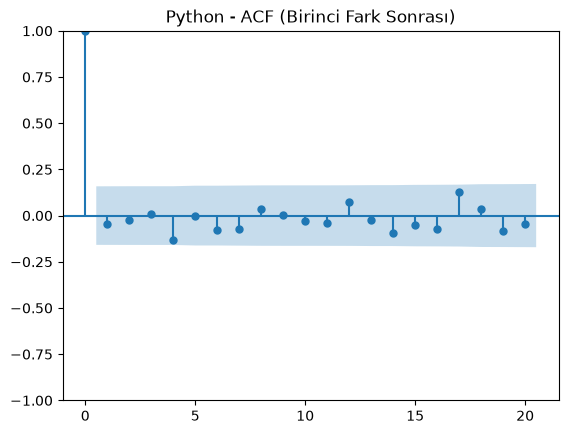

In [16]:
# ACF ve PACF grafikleri için
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## Çok fazla grafik üretmemek için önce örnek anahtar kelimenin ACF grafiğine bakıyoruz.
## İstenirse sample_keyword değiştirilerek başka bir seri incelenebilir.

acf_lags = min(20, max(1, len(train_diff[sample_keyword]) // 2 - 1))

plot_acf(
    train_diff[sample_keyword],
    lags=acf_lags
)

plt.title(f"{sample_keyword} - ACF (Birinci Fark Sonrası)")
plt.show()


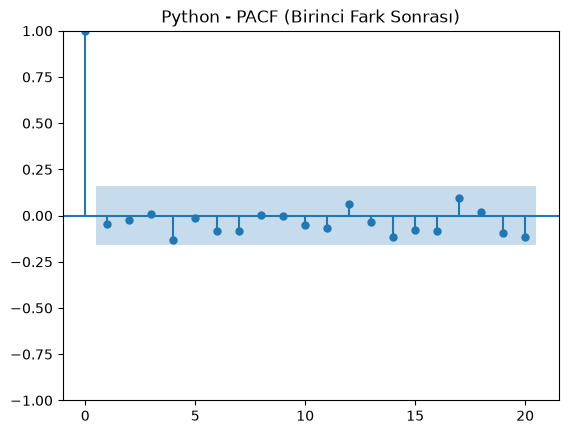

In [17]:
## Örnek anahtar kelimenin PACF grafiğini çiziyoruz.

pacf_lags = min(20, max(1, len(train_diff[sample_keyword]) // 2 - 1))

plot_pacf(
    train_diff[sample_keyword],
    lags=pacf_lags
)

plt.title(f"{sample_keyword} - PACF (Birinci Fark Sonrası)")
plt.show()


In [18]:
## Her anahtar kelime için ARIMA aday modellerini deniyoruz.
## p ve q değerlerini 0, 1 ve 2; d değerini 1 olarak kullanıyoruz.

arima_results = []

for keyword in keywords:

    for p in range(3):

        for q in range(3):

            order = (p, 1, q)

            try:
                model = ARIMA(
                    train_series[keyword],
                    order=order
                )

                fitted_model = model.fit()

                arima_results.append({
                    "keyword": keyword,
                    "order": order,
                    "AIC": fitted_model.aic,
                    "BIC": fitted_model.bic
                })

            except Exception as error:
                print(
                    f"{keyword} - ARIMA{order} kurulamadı:",
                    error
                )


c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_fo

In [19]:
## Aday model sonuçlarını DataFrame'e dönüştürüyoruz.

arima_selection_df = pd.DataFrame(arima_results)

arima_selection_df = (
    arima_selection_df
    .sort_values(["keyword", "AIC"])
    .reset_index(drop=True)
)

## Her anahtar kelime için en düşük AIC değerine sahip modeli seçiyoruz.
selected_orders = (
    arima_selection_df
    .groupby("keyword", sort=False)
    .first()["order"]
    .to_dict()
)

print("Seçilen ARIMA dereceleri:")
for keyword in keywords:
    print(keyword, "->", selected_orders[keyword])

arima_selection_df


Seçilen ARIMA dereceleri:
Python -> (1, 1, 1)
SQL -> (1, 1, 1)


,keyword,order,AIC,BIC
0,Python,"(1, 1, 1)",944.617461,953.708775
1,Python,"(1, 1, 2)",946.570422,958.692173
2,Python,"(2, 1, 2)",946.605363,961.757553
3,Python,"(0, 1, 0)",949.483049,952.513487
4,Python,"(0, 1, 1)",951.085618,957.146494
5,Python,"(1, 1, 0)",951.105430,957.166306
6,Python,"(2, 1, 1)",952.841420,964.963172
7,Python,"(0, 1, 2)",952.966048,962.057362
8,Python,"(2, 1, 0)",953.006791,962.098105
9,SQL,"(1, 1, 1)",687.498990,696.590304


#### ARIMA Model Seçimi

Her anahtar kelime ayrı bir zaman serisi olduğu için tek bir ARIMA derecesini bütün sütunlara zorlamıyoruz.

Her seri için `p = 0,1,2` ve `q = 0,1,2` kombinasyonları, `d = 1` olacak şekilde denenir. Aday modeller AIC ve BIC bilgi kriterleriyle karşılaştırılır ve her anahtar kelime için en düşük AIC değerine sahip model seçilir.


In [20]:
## Her anahtar kelimeyi kendi seçilen ARIMA derecesiyle eğitiyoruz.

arima_fitted = {}

for keyword in keywords:
    selected_order = selected_orders[keyword]

    model = ARIMA(
        train_series[keyword],
        order=selected_order
    )

    arima_fitted[keyword] = model.fit()


c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_fo

In [21]:
## Örnek anahtar kelimenin model özetini inceliyoruz.

print("Anahtar kelime:", sample_keyword)
print("ARIMA derecesi:", selected_orders[sample_keyword])
print(arima_fitted[sample_keyword].summary())


Anahtar kelime: Python
ARIMA derecesi: (1, 1, 1)
                               SARIMAX Results                                
Dep. Variable:                 Python   No. Observations:                  154
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -469.309
Date:                Fri, 28 Aug 2026   AIC                            944.617
Time:                        14:11:27   BIC                            953.709
Sample:                    08-06-2023   HQIC                           948.311
                         - 07-12-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8606      0.054     15.933      0.000       0.755       0.967
ma.L1         -0.9989      0.329     -3.040      0.002      -1.643      -0.355
sig

In [22]:
## Her anahtar kelime için test seti uzunluğu kadar ileri tahmin üretiyoruz.

arima_test_forecasts = {}

for keyword in keywords:
    arima_test_forecasts[keyword] = arima_fitted[keyword].forecast(
        steps=len(test_series[keyword])
    )


In [23]:
## Test gözlem sayıları.

{
    keyword: len(test_series[keyword])
    for keyword in keywords
}


{'Python': 4, 'SQL': 4}

In [24]:
## Tahminlerin tarih indexini gerçek test tarihleriyle eşleştiriyoruz.

for keyword in keywords:
    arima_test_forecasts[keyword].index = test_series[keyword].index


In [25]:
## Her anahtar kelime için gerçek test değerlerini ve tahminleri birleştiriyoruz.

arima_results_by_keyword = {}

for keyword in keywords:
    arima_results_by_keyword[keyword] = pd.DataFrame({
        "actual": test_series[keyword],
        "predicted": arima_test_forecasts[keyword]
    })

## Bütün anahtar kelimeleri tek tabloda da tutuyoruz.
all_arima_results_df = pd.concat(
    [
        result.assign(keyword=keyword).reset_index()
        for keyword, result in arima_results_by_keyword.items()
    ],
    ignore_index=True
)[["keyword", "date", "actual", "predicted"]]

all_arima_results_df


,keyword,date,actual,predicted
0,Python,2026-07-19,61.0,58.976770
1,Python,2026-07-26,62.0,59.817413
2,Python,2026-08-02,57.0,60.540899
3,Python,2026-08-09,48.0,61.163557
4,SQL,2026-07-19,25.0,21.482371
5,SQL,2026-07-26,20.0,22.452686
6,SQL,2026-08-02,18.0,23.087823
7,SQL,2026-08-09,17.0,23.503565


#### Tek Test Döneminde Hata Metrikleri


In [26]:
# Tahmin hatalarını ölçmek için MAE ve RMSE kullanıyoruz.
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

metric_rows = []

for keyword in keywords:
    result_df = arima_results_by_keyword[keyword]

    mae = mean_absolute_error(
        result_df["actual"],
        result_df["predicted"]
    )

    rmse = root_mean_squared_error(
        result_df["actual"],
        result_df["predicted"]
    )

    metric_rows.append({
        "keyword": keyword,
        "order": selected_orders[keyword],
        "MAE": mae,
        "RMSE": rmse
    })

metrics_df = (
    pd.DataFrame(metric_rows)
    .sort_values("MAE")
    .reset_index(drop=True)
)

metrics_df.round(2)


,keyword,order,MAE,RMSE
0,SQL,"(1, 1, 1)",4.39,4.65
1,Python,"(1, 1, 1)",5.23,6.98


In [27]:
## Cross-validation için her anahtar kelimenin tüm serisini kullanıyoruz.

full_series = {
    keyword: series[keyword].copy()
    for keyword in keywords
}


#### Zaman Serisine Uygun Basit Cross-Validation

Yukarıdaki MAE/RMSE tek bir test döneminden (son 4 hafta) geliyor. Bu sonucun şansa mı bağlı olduğunu, yoksa modelin genel olarak mı böyle davrandığını anlamak için aynı modeli **3 farklı zaman noktasında** ayrı ayrı test ediyoruz.

Mantık: veriyi belirli bir noktadan (cutoff) kesiyoruz, o noktaya kadar olan kısımla model eğitip sonraki 4 haftayı tahmin ediyoruz. Bunu 3 farklı cutoff için tekrarlıyoruz.

(Prophet'te bunun için hazır `cross_validation()` fonksiyonunu kullanmıştık; statsmodels'de böyle hazır bir fonksiyon olmadığı için burada manuel/basit bir şekilde yapıyoruz.)


In [28]:
## Statsmodels için manuel time-series cross-validation.
## Veri setimiz yaklaşık 158 haftalık olduğu için özgün notebooktaki
## 100, 130 ve son test başlangıcı civarındaki cutoff mantığını koruyoruz.

cv_results_list = []

for keyword in keywords:

    current_series = full_series[keyword]
    n = len(current_series)

    candidate_cutoffs = [100, 130, n - forecast_steps]

    ## Aynı veya geçersiz cutoff değerlerini temizliyoruz.
    cutoffs = sorted({
        cutoff
        for cutoff in candidate_cutoffs
        if cutoff > 10 and cutoff + forecast_steps <= n
    })

    for cutoff in cutoffs:

        train_part = current_series.iloc[:cutoff]
        test_part = current_series.iloc[
            cutoff: cutoff + forecast_steps
        ]

        if len(test_part) < forecast_steps:
            continue

        try:
            model = ARIMA(
                train_part,
                order=selected_orders[keyword]
            )

            fitted = model.fit()

            forecast = fitted.forecast(
                steps=forecast_steps
            )

            forecast.index = test_part.index

            mae = mean_absolute_error(
                test_part,
                forecast
            )

            rmse = root_mean_squared_error(
                test_part,
                forecast
            )

            cv_results_list.append({
                "keyword": keyword,
                "order": selected_orders[keyword],
                "cutoff_date": train_part.index[-1],
                "mae": mae,
                "rmse": rmse
            })

            print(
                f"{keyword} | "
                f"Cutoff: {train_part.index[-1].date()} | "
                f"MAE: {mae:.2f} | RMSE: {rmse:.2f}"
            )

        except Exception as error:
            print(
                f"{keyword} cutoff {cutoff} için model kurulamadı:",
                error
            )


c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_fo

Python | Cutoff: 2025-06-29 | MAE: 2.12 | RMSE: 2.28
Python | Cutoff: 2026-01-25 | MAE: 7.15 | RMSE: 8.97


c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_fo

Python | Cutoff: 2026-07-12 | MAE: 5.23 | RMSE: 6.98
SQL | Cutoff: 2025-06-29 | MAE: 0.51 | RMSE: 0.58
SQL | Cutoff: 2026-01-25 | MAE: 1.87 | RMSE: 2.66
SQL | Cutoff: 2026-07-12 | MAE: 4.39 | RMSE: 4.65


c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


In [29]:
## Cross-validation sonuçları.

cv_results_df = pd.DataFrame(cv_results_list)
cv_results_df


,keyword,order,cutoff_date,mae,rmse
0,Python,"(1, 1, 1)",2025-06-29,2.124266,2.280998
1,Python,"(1, 1, 1)",2026-01-25,7.151407,8.967872
2,Python,"(1, 1, 1)",2026-07-12,5.227568,6.976288
3,SQL,"(1, 1, 1)",2025-06-29,0.509344,0.576642
4,SQL,"(1, 1, 1)",2026-01-25,1.869414,2.655959
5,SQL,"(1, 1, 1)",2026-07-12,4.390426,4.652195


In [30]:
## Her anahtar kelime için ortalama CV MAE ve RMSE.

if cv_results_df.empty:
    cv_summary_df = pd.DataFrame(
        columns=["keyword", "cv_mae", "cv_rmse"]
    )
else:
    cv_summary_df = (
        cv_results_df
        .groupby("keyword", as_index=False)
        .agg(
            cv_mae=("mae", "mean"),
            cv_rmse=("rmse", "mean")
        )
        .sort_values("cv_mae")
        .reset_index(drop=True)
    )

cv_summary_df.round(2)


,keyword,cv_mae,cv_rmse
0,SQL,2.26,2.63
1,Python,4.83,6.08


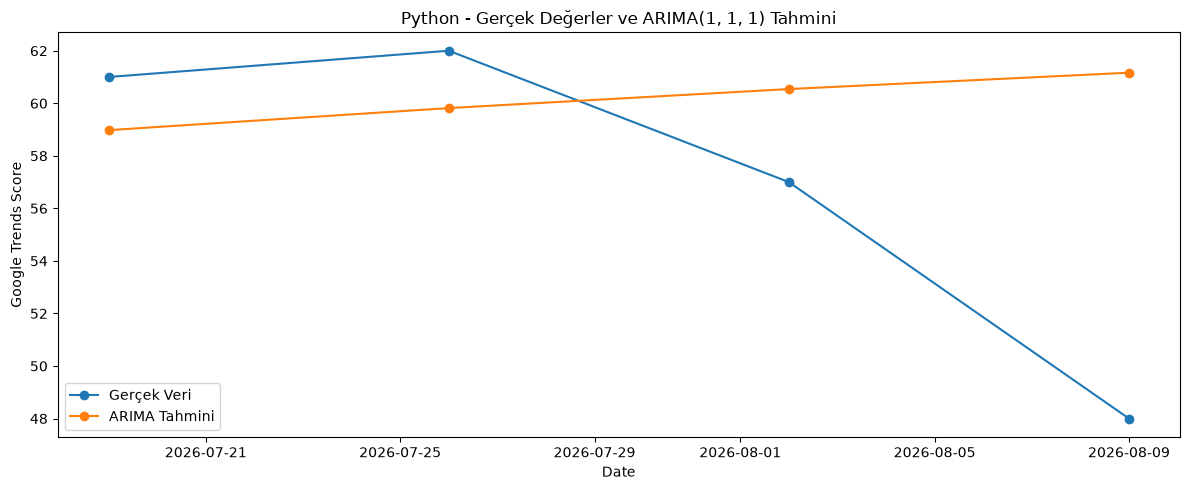

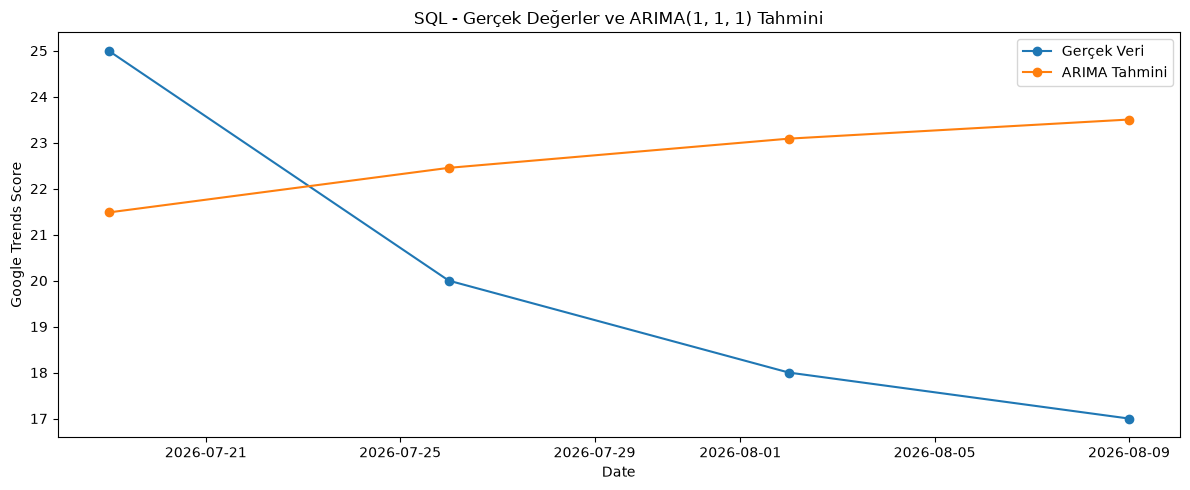

In [31]:
## Her anahtar kelime için test dönemindeki gerçek değerleri
## ve ARIMA tahminlerini ayrı grafiklerde gösteriyoruz.

for keyword in keywords:
    result_df = arima_results_by_keyword[keyword]

    plt.figure(figsize=(12, 5))

    plt.plot(
        result_df.index,
        result_df["actual"],
        marker="o",
        label="Gerçek Veri"
    )

    plt.plot(
        result_df.index,
        result_df["predicted"],
        marker="o",
        label="ARIMA Tahmini"
    )

    plt.title(
        f"{keyword} - Gerçek Değerler ve "
        f"ARIMA{selected_orders[keyword]} Tahmini"
    )

    plt.xlabel("Date")
    plt.ylabel("Google Trends Score")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [32]:
## Bütün anahtar kelimelerin test tahminlerini birlikte inceliyoruz.

all_arima_results_df


,keyword,date,actual,predicted
0,Python,2026-07-19,61.0,58.976770
1,Python,2026-07-26,62.0,59.817413
2,Python,2026-08-02,57.0,60.540899
3,Python,2026-08-09,48.0,61.163557
4,SQL,2026-07-19,25.0,21.482371
5,SQL,2026-07-26,20.0,22.452686
6,SQL,2026-08-02,18.0,23.087823
7,SQL,2026-08-09,17.0,23.503565


In [33]:
## Yaklaşık 30 günlük gelecek tahmini
## Verimiz haftalık olduğu için 4 ileri hafta tahmin ediyoruz.
## Final modelleri train+test dahil tüm geçmiş veri üzerinde yeniden eğitiyoruz.

future_rows = []
final_models = {}

for keyword in keywords:
    current_series = full_series[keyword]

    final_model = ARIMA(
        current_series,
        order=selected_orders[keyword]
    ).fit()

    final_models[keyword] = final_model

    prediction = final_model.get_forecast(
        steps=forecast_steps
    )

    predicted_mean = np.asarray(
        prediction.predicted_mean
    )

    conf_int = prediction.conf_int(
        alpha=0.05
    )

    lower = np.asarray(conf_int.iloc[:, 0])
    upper = np.asarray(conf_int.iloc[:, 1])

    last_date = current_series.index.max()

    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(weeks=1),
        periods=forecast_steps,
        freq="W-SUN"
    )

    for date, yhat, yhat_lower, yhat_upper in zip(
        future_dates,
        predicted_mean,
        lower,
        upper
    ):
        future_rows.append({
            "keyword": keyword,
            "date": date,
            "yhat": yhat,
            "yhat_lower": yhat_lower,
            "yhat_upper": yhat_upper
        })

future_forecast_df = pd.DataFrame(future_rows)

forecast_columns = [
    "yhat",
    "yhat_lower",
    "yhat_upper"
]

future_forecast_df[forecast_columns] = (
    future_forecast_df[forecast_columns]
    .round(2)
)

future_forecast_df


c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\sanug\OneDrive\Desktop\trend_fo

,keyword,date,yhat,yhat_lower,yhat_upper
0,Python,2026-08-16,50.19,40.02,60.36
1,Python,2026-08-23,52.09,38.59,65.58
2,Python,2026-08-30,53.73,38.17,69.29
3,Python,2026-09-06,55.16,38.18,72.13
4,SQL,2026-08-16,18.92,14.44,23.41
5,SQL,2026-08-23,20.22,14.66,25.78
6,SQL,2026-08-30,21.09,15.00,27.18
7,SQL,2026-09-06,21.67,15.28,28.07
